# September 2026 — raw models (no adjustments) with prediction intervals, desktop and mobile

The live September configs re-run at the **2026-09-09** seam (training through 2026-09-08) on the same cached
raw pulls the canonical builds used, with **every adjustment off**:

- **Desktop** (g01): `i` / `j` / `l` / `o` disabled, `h` not applied (display layer). Build: `desktop_raw_ci_2026-09-09/`.
- **Mobile** (cpr 0.725): the paid/organic split `p` **off**, so Prophet fits **total** mobile DAU — this is not an
  organic forecast; `t` / `u` not applied. Build: `mobile_raw_ci_2026-09-09/`.

Iran fill on for both. Intervals are Prophet predictive intervals taken as **quantiles of the 28-day trailing mean
across the 1,000 stored sample paths**, not calibrated. Not canonical; changes nothing published. Each build's
`_index.md` has the full write-up.

Cells: `[setup]` → `[recompute-intervals]` (optional, re-reads both pickles) → `[dec15-table]` → `[plot-28ma]` →
`[plot-zoom]` → `[method-check]` → `[dec15-bounds-table]` (raw point forecast, bounds, full width, both platforms).


In [1]:
# [setup]
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src" / "mozaic_daily").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

FORECAST_START = "2026-09-09"
ANCHOR_DATE = pd.Timestamp("2026-12-15")
LEVELS = ["50", "80", "90"]
CYCLE_DIR = REPO_ROOT / "data-official/2026-09"

# One entry per raw-model build. `world_filter` selects the world-total row of that platform's parquet.
BUILDS = {
    "Desktop": {
        "build_dir": CYCLE_DIR / "desktop_raw_ci_2026-09-09",
        "slug": "cps0.1649_thresh032_recent17_cpr0.814_ncp40_clip0.6_sps0.00825_regimemultiplicative",
        "pkl_name": f"mozaic_objects.legacy_desktop.{FORECAST_START}.pkl",
        "parquet_name": f"mozaic_daily_forecast.{FORECAST_START}.ld-D.raw.parquet",
        "stem": "desktop_raw",
        "model_label": "raw g01 model (i j l o off, h not applied)",
        "world_filter": lambda df: (df["country"] == "ALL") & (df["segment"] == '{"os": "ALL"}'),
    },
    "Mobile": {
        "build_dir": CYCLE_DIR / "mobile_raw_ci_2026-09-09",
        "slug": "cps0.035_thresh055_recent13_cpr0.725_ncp25_clip0.6_sps0.1",
        "pkl_name": f"mozaic_objects.glean_mobile.{FORECAST_START}.pkl",
        "parquet_name": f"mozaic_daily_forecast.{FORECAST_START}.gm-D.raw.parquet",
        "stem": "mobile_raw",
        "model_label": "raw cpr0.725 model (p off = total-DAU fit, t u not applied)",
        "world_filter": lambda df: (df["country"] == "ALL") & (df["segment"] == "{}") & (df["app_name"] == "ALL MOBILE"),
    },
}
for platform, b in BUILDS.items():
    b["pkl"] = b["build_dir"] / b["slug"] / b["pkl_name"]
    b["parquet"] = b["build_dir"] / b["slug"] / b["parquet_name"]
    print(f"{platform:8s} build dir {b['build_dir'].relative_to(REPO_ROOT)}  pkl {b['pkl'].exists()}  parquet {b['parquet'].exists()}")


Desktop  build dir data-official/2026-09/desktop_raw_ci_2026-09-09  pkl True  parquet True
Mobile   build dir data-official/2026-09/mobile_raw_ci_2026-09-09  pkl True  parquet True


In [2]:
# [recompute-intervals]
# Re-derives each build's csv/, plots/ and <stem>_summary.json from its pickle. Skipped per build when the
# pickle is not on disk (gitignored; restore from the GCS archive named in the build's _index.md).
for platform, b in BUILDS.items():
    print(f"── {platform}")
    if not b["pkl"].exists():
        print(f"Pickle not on disk ({b['pkl'].name}); using the committed csv/ and summary outputs as-is.")
        continue
    cmd = [sys.executable, str(REPO_ROOT / "scripts/compute_forecast_intervals.py"),
           "--pkl", str(b["pkl"]), "--forecast-parquet", str(b["parquet"]), "--out-dir", str(b["build_dir"])]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print("\n".join(line for line in result.stdout.splitlines() if "Warning" not in line))
    if result.returncode != 0:
        print(result.stderr[-3000:])
        raise RuntimeError(f"compute_forecast_intervals.py exited {result.returncode} for {platform}")


── Desktop


Loading pickle /Users/brendanwells/work/mozaic-daily/data-official/2026-09/desktop_raw_ci_2026-09-09/cps0.1649_thresh032_recent17_cpr0.814_ncp40_clip0.6_sps0.00825_regimemultiplicative/mozaic_objects.legacy_desktop.2026-09-09.pkl ...
Median path reproduces the parquet world forecast (worst |dev| 0.0000 DAU) — 1000 paths

desktop_raw 28d-MA on 2026-12-15: point forecast 50,326,587 (trailing mean of the median path); band-centre median 50,314,819
  50%: [49,981,810, 50,678,498]  half-width 348,344
  80%: [49,174,397, 51,642,334]  half-width 1,233,969
  90%: [48,477,503, 52,425,191]  half-width 1,973,844
Trough (28d-MA median) 2026-09-09: 47,327,703

Wrote /Users/brendanwells/work/mozaic-daily/data-official/2026-09/desktop_raw_ci_2026-09-09/csv/desktop_raw_*.csv, /Users/brendanwells/work/mozaic-daily/data-official/2026-09/desktop_raw_ci_2026-09-09/plots/desktop_raw_*.png, /Users/brendanwells/work/mozaic-daily/data-official/2026-09/desktop_raw_ci_2026-09-09/desktop_raw_summary.json
── Mobi

Loading pickle /Users/brendanwells/work/mozaic-daily/data-official/2026-09/mobile_raw_ci_2026-09-09/cps0.035_thresh055_recent13_cpr0.725_ncp25_clip0.6_sps0.1/mozaic_objects.glean_mobile.2026-09-09.pkl ...
Median path reproduces the parquet world forecast (worst |dev| 0.0000 DAU) — 1000 paths

mobile_raw 28d-MA on 2026-12-15: point forecast 17,706,153 (trailing mean of the median path); band-centre median 17,702,093
  50%: [17,656,474, 17,751,841]  half-width 47,684
  80%: [17,566,833, 17,841,561]  half-width 137,364
  90%: [17,486,488, 17,966,102]  half-width 239,807
Trough (28d-MA median) 2026-09-30: 17,298,375

Wrote /Users/brendanwells/work/mozaic-daily/data-official/2026-09/mobile_raw_ci_2026-09-09/csv/mobile_raw_*.csv, /Users/brendanwells/work/mozaic-daily/data-official/2026-09/mobile_raw_ci_2026-09-09/plots/mobile_raw_*.png, /Users/brendanwells/work/mozaic-daily/data-official/2026-09/mobile_raw_ci_2026-09-09/mobile_raw_summary.json


In [3]:
# [dec15-table]
fmt = lambda v: "" if pd.isna(v) else f"{v:,.0f}"
summaries = {}
for platform, b in BUILDS.items():
    summary = json.loads((b["build_dir"] / f"{b['stem']}_summary.json").read_text())
    summaries[platform] = summary
    anchor = summary["anchor_28ma"]
    rows = [("raw model point forecast (mean of median path)", anchor["point_forecast_28ma"], None, None),
            ("raw model band centre (median of path means)", anchor["median"], None, None)]
    for pct in LEVELS:
        rows.append((f"{pct}% interval", None, anchor[f"lower_{pct}"], anchor[f"upper_{pct}"]))
    table = pd.DataFrame(rows, columns=["series", "value", "lower", "upper"])
    table["half_width"] = (table["upper"] - table["lower"]) / 2
    print(f"{platform} world 28d-MA on {anchor['date']}  (seam {summary['forecast_start_date']}, {summary['n_sample_paths']} paths)\n")
    print(table.to_string(index=False, formatters={c: fmt for c in ["value", "lower", "upper", "half_width"]}))
    print(f"median path vs parquet worst |dev|: {summary['median_vs_parquet_worst_abs_dev']:.4f} DAU")
    print("(the summary's trough field is not meaningful at a September seam — its window starts before the seam)\n")


Desktop world 28d-MA on 2026-12-15  (seam 2026-09-09, 1000 paths)

                                        series      value      lower      upper half_width
raw model point forecast (mean of median path) 50,326,587        NaN        NaN        NaN
  raw model band centre (median of path means) 50,314,819        NaN        NaN        NaN
                                  50% interval        NaN 49,981,810 50,678,498    348,344
                                  80% interval        NaN 49,174,397 51,642,334  1,233,969
                                  90% interval        NaN 48,477,503 52,425,191  1,973,844
median path vs parquet worst |dev|: 0.0000 DAU
(the summary's trough field is not meaningful at a September seam — its window starts before the seam)

Mobile world 28d-MA on 2026-12-15  (seam 2026-09-09, 1000 paths)

                                        series      value      lower      upper half_width
raw model point forecast (mean of median path) 17,706,153        NaN        NaN

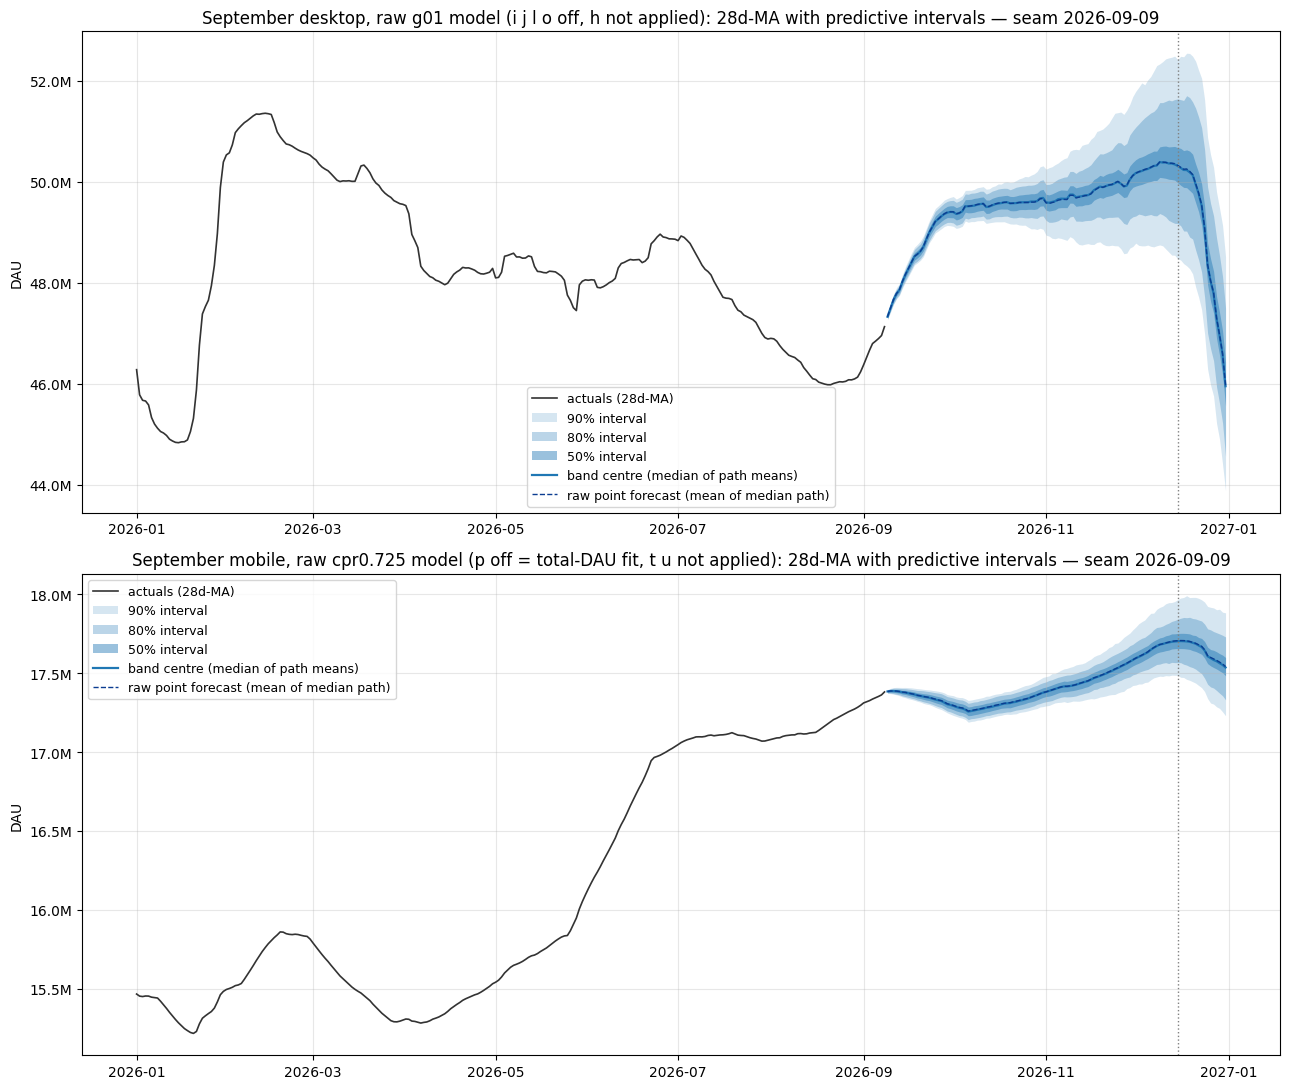

saved data-official/2026-09/plots/raw_intervals_28ma_bands.png


In [4]:
# [plot-28ma]
ALPHAS = {"50": 0.45, "80": 0.30, "90": 0.18}
bands = {}  # platform -> {"ma": 28d-MA band frame, "daily": daily band frame}
for platform, b in BUILDS.items():
    csv_dir = b["build_dir"] / "csv"
    bands[platform] = {
        "ma": pd.read_csv(csv_dir / f"{b['stem']}_28ma_bands.csv", parse_dates=["date"]).set_index("date"),
        "daily": pd.read_csv(csv_dir / f"{b['stem']}_daily_bands.csv", parse_dates=["date"]).set_index("date"),
    }


def draw_bands(ax, frame, decimals=1, show_point_forecast=True):
    for pct in sorted(LEVELS, key=int, reverse=True):
        ax.fill_between(frame.index, frame[f"lower_{pct}"], frame[f"upper_{pct}"],
                        color="#1f77b4", alpha=ALPHAS[pct], linewidth=0, label=f"{pct}% interval")
    ax.plot(frame.index, frame["median"], color="#1f77b4", linewidth=1.6, label="band centre (median of path means)")
    if show_point_forecast and "point_forecast_28ma" in frame:
        ax.plot(frame.index, frame["point_forecast_28ma"], color="#0b3d91", linewidth=1.0, linestyle="--",
                label="raw point forecast (mean of median path)")
    ax.axvline(ANCHOR_DATE, color="grey", linestyle=":", linewidth=1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e6:.{decimals}f}M"))
    ax.set_ylabel("DAU")
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(len(BUILDS), 1, figsize=(13, 5.5 * len(BUILDS)))
for ax, (platform, b) in zip(axes, BUILDS.items()):
    ma = bands[platform]["ma"]
    ax.plot(ma.index, ma["actuals_28ma"], color="#333333", linewidth=1.2, label="actuals (28d-MA)")
    draw_bands(ax, ma)
    ax.set_title(f"September {platform.lower()}, {b['model_label']}: 28d-MA with predictive intervals — seam {FORECAST_START}")
    ax.legend(loc="best", fontsize=9)
fig.tight_layout()
out_path = CYCLE_DIR / "plots" / "raw_intervals_28ma_bands.png"
fig.savefig(out_path, dpi=130)
plt.show()
print(f"saved {out_path.relative_to(REPO_ROOT)}")


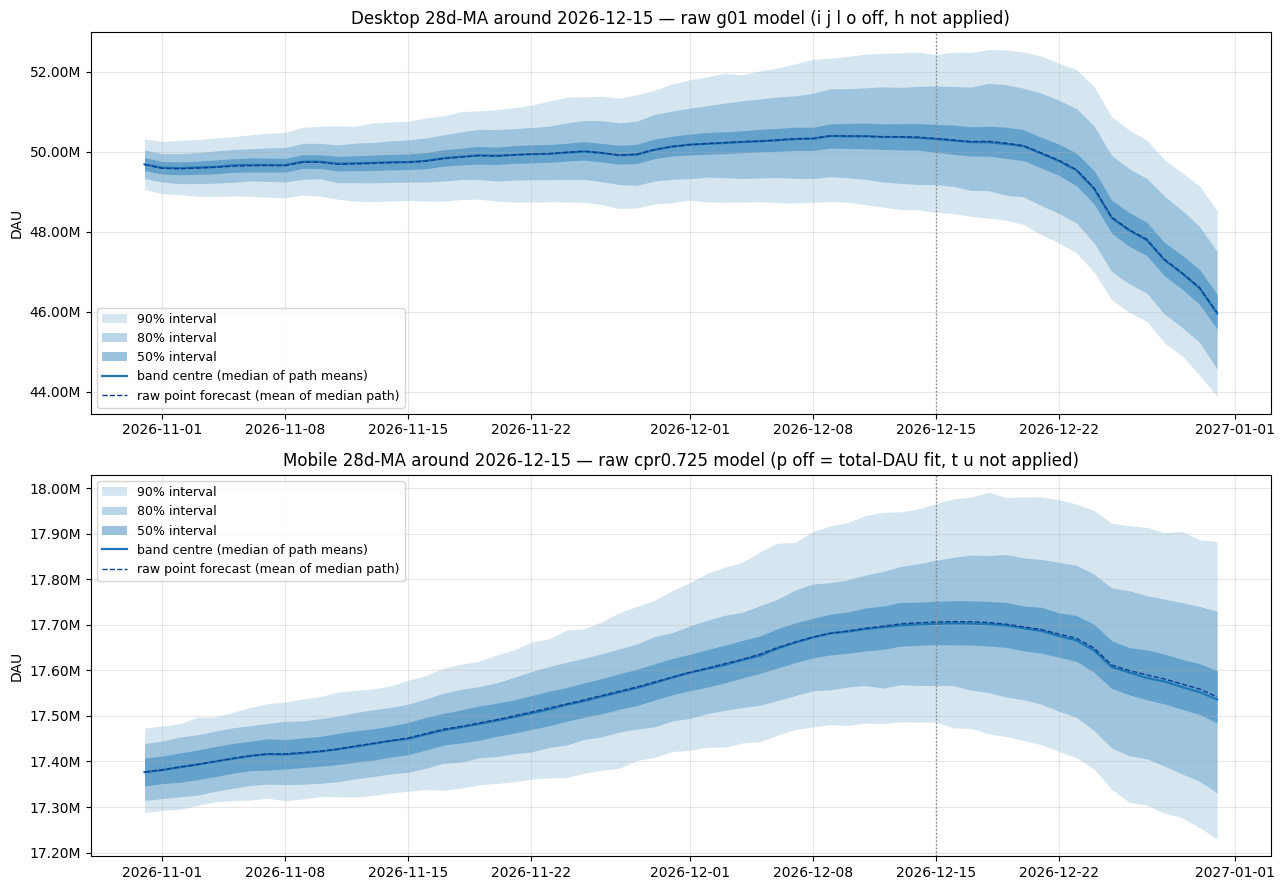

Desktop: 28d-MA band width (upper − lower) by date
                 50         80         90
date                                     
2026-09-09   50,254     92,856    118,776
2026-10-01  238,151    447,480    589,691
2026-11-01  315,527    709,906  1,308,300
2026-12-15  696,688  2,467,937  3,947,688
2026-12-31  873,316  2,937,258  4,641,266 

Mobile: 28d-MA band width (upper − lower) by date
                 50       80       90
date                                 
2026-09-09    9,895   18,271   23,393
2026-10-01   51,729   95,381  125,447
2026-11-01   60,299  126,439  185,299
2026-12-15   95,367  274,728  479,614
2026-12-31  115,602  398,741  652,725 



In [5]:
# [plot-zoom]
fig, axes = plt.subplots(len(BUILDS), 1, figsize=(13, 4.5 * len(BUILDS)))
for ax, (platform, b) in zip(axes, BUILDS.items()):
    ma = bands[platform]["ma"]
    zoom = ma.loc[ANCHOR_DATE - pd.Timedelta(days=45): ANCHOR_DATE + pd.Timedelta(days=16)]
    draw_bands(ax, zoom, decimals=2)
    ax.set_title(f"{platform} 28d-MA around {ANCHOR_DATE.date()} — {b['model_label']}")
    ax.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()

# Band width over the horizon: how fast each model's own uncertainty grows.
checkpoints = [pd.Timestamp(d) for d in [FORECAST_START, "2026-10-01", "2026-11-01", "2026-12-15", "2026-12-31"]]
for platform in BUILDS:
    ma = bands[platform]["ma"]
    width = pd.DataFrame({pct: ma[f"upper_{pct}"] - ma[f"lower_{pct}"] for pct in LEVELS}).dropna()
    print(f"{platform}: 28d-MA band width (upper − lower) by date")
    print(width.loc[checkpoints].map(lambda v: f"{v:,.0f}").to_string(), "\n")


In [6]:
# [method-check]
# Two facts a reader should be able to verify from the CSVs alone, without the pickle, for each build.
from mozaic_daily.adjustments import load_forecast  # noqa: E402  (path set in [setup])

for platform, b in BUILDS.items():
    print(f"── {platform}")
    ma, daily = bands[platform]["ma"], bands[platform]["daily"]

    # 1. The point forecast column is a plain trailing-28 mean of (actuals, then parquet forecast).
    df, meta = load_forecast(str(b["parquet"]))
    world = df[b["world_filter"](df)].copy()
    assert not world["target_date"].duplicated().any(), f"{platform}: world filter is not one row per date"
    world["target_date"] = pd.to_datetime(world["target_date"])
    world = world.set_index("target_date").sort_index()["dau"]
    dev = (world.rolling(28).mean().reindex(ma.index) - ma["point_forecast_28ma"]).abs().dropna()
    print(f"point_forecast_28ma == rolling(28) of the parquet world series: worst |dev| {dev.max():.6f} DAU")
    assert dev.max() <= 0.005 + 1e-9  # the CSV is written at two decimals
    print(f"adjustments in the parquet sidecar: {meta['adjustments_applied'] or 'none (raw)'}")

    # 2. The MA band is narrower than the daily band on the same date — the signature of taking
    #    quantiles AFTER averaging (day-to-day noise cancels inside the window).
    d, m = daily.loc[ANCHOR_DATE], ma.loc[ANCHOR_DATE]
    for pct in LEVELS:
        daily_w, ma_w = d[f"upper_{pct}"] - d[f"lower_{pct}"], m[f"upper_{pct}"] - m[f"lower_{pct}"]
        print(f"{pct}% width on {ANCHOR_DATE.date()}: daily {daily_w:,.0f}  28d-MA {ma_w:,.0f}  ratio {ma_w / daily_w:.2f}")
        assert ma_w < daily_w
    print()


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_st

── Desktop
point_forecast_28ma == rolling(28) of the parquet world series: worst |dev| 0.004857 DAU
adjustments in the parquet sidecar: none (raw)
50% width on 2026-12-15: daily 2,210,518  28d-MA 696,688  ratio 0.32
80% width on 2026-12-15: daily 4,629,796  28d-MA 2,467,937  ratio 0.53
90% width on 2026-12-15: daily 6,664,378  28d-MA 3,947,688  ratio 0.59

── Mobile
point_forecast_28ma == rolling(28) of the parquet world series: worst |dev| 0.004909 DAU
adjustments in the parquet sidecar: none (raw)
50% width on 2026-12-15: daily 342,501  28d-MA 95,367  ratio 0.28
80% width on 2026-12-15: daily 678,742  28d-MA 274,728  ratio 0.40
90% width on 2026-12-15: daily 879,428  28d-MA 479,614  ratio 0.55



In [7]:
# [dec15-bounds-table]
# Both platforms' raw-model Dec-15 28d-MA in one table: the published-convention point forecast
# ("raw point forecast" = trailing mean of the median path) with each interval's bounds and full width.
rows = []
for platform, summary in summaries.items():
    anchor = summary["anchor_28ma"]
    for pct in LEVELS:
        lower, upper = anchor[f"lower_{pct}"], anchor[f"upper_{pct}"]
        rows.append({"platform": platform, "interval": f"{pct}%", "raw point forecast": anchor["point_forecast_28ma"],
                     "lower": lower, "upper": upper, "full width": upper - lower})

bounds_table = pd.DataFrame(rows)
print(f"Raw-model 28d-MA on {anchor['date']}, all adjustments off (seam {FORECAST_START})\n")
print(bounds_table.to_string(index=False, formatters={c: (lambda v: f"{v:,.0f}") for c in ["raw point forecast", "lower", "upper", "full width"]}))


Raw-model 28d-MA on 2026-12-15, all adjustments off (seam 2026-09-09)

platform interval raw point forecast      lower      upper full width
 Desktop      50%         50,326,587 49,981,810 50,678,498    696,688
 Desktop      80%         50,326,587 49,174,397 51,642,334  2,467,937
 Desktop      90%         50,326,587 48,477,503 52,425,191  3,947,688
  Mobile      50%         17,706,153 17,656,474 17,751,841     95,367
  Mobile      80%         17,706,153 17,566,833 17,841,561    274,728
  Mobile      90%         17,706,153 17,486,488 17,966,102    479,614
